# 01 – Data Exploration

Walks through LinearSCM-T, visualises trajectories, and inspects causal coefficient matrices.


In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from causaltemp_xai.benchmark import LinearSCMT

sns.set_theme(style='whitegrid', palette='tab10')


## 1. Generate Data


In [4]:
N_VARS = 5
LAG    = 2
T      = 50
N      = 200

generator = LinearSCMT(n_vars=N_VARS, lag=LAG, seed=42)
X, y = generator.sample_with_labels(n_samples=N, T=T, target_var=0)

print(f'Data shape : {X.shape}')
print(f'Class dist : {np.bincount(y)}')


Data shape : (200, 50, 5)
Class dist : [101  99]


## 2. Visualise Sample Trajectories


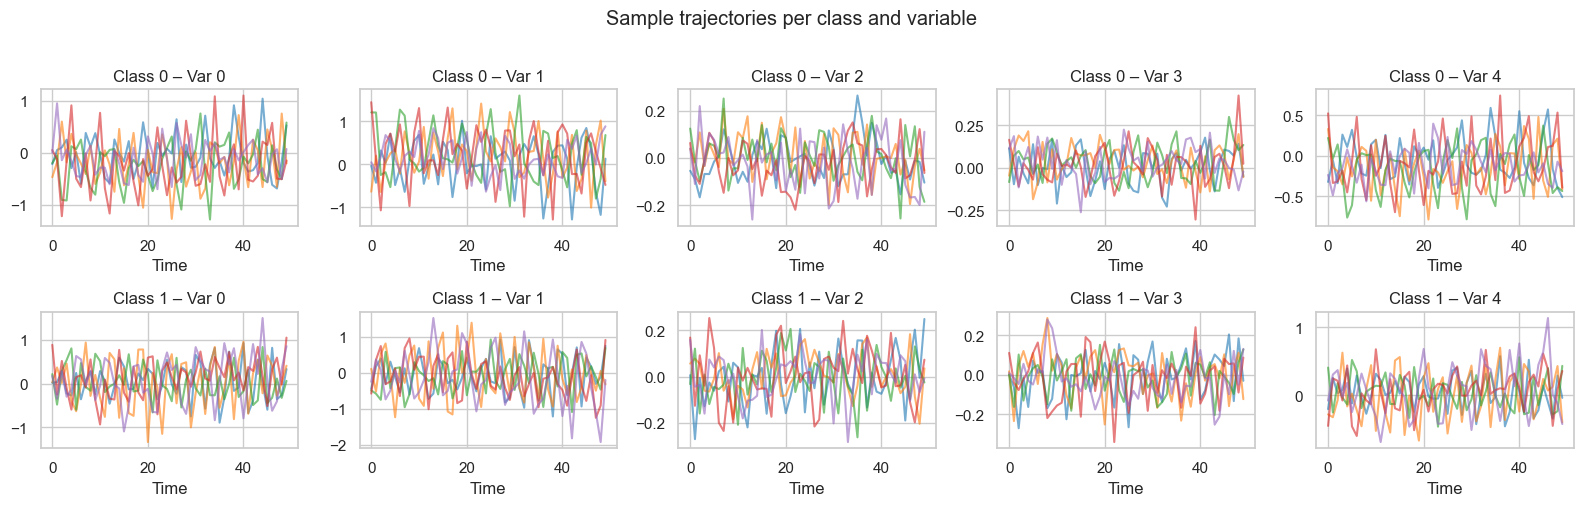

In [5]:
fig, axes = plt.subplots(2, N_VARS, figsize=(16, 5), sharey=False)

for cls, ax_row in enumerate(axes):
    idx = np.where(y == cls)[0][:5]
    for ax, var in zip(ax_row, range(N_VARS)):
        for i in idx:
            ax.plot(X[i, :, var], alpha=0.6)
        ax.set_title(f'Class {cls} – Var {var}')
        ax.set_xlabel('Time')

plt.suptitle('Sample trajectories per class and variable', y=1.01)
plt.tight_layout()
plt.show()


## 3. Causal Coefficient Matrices


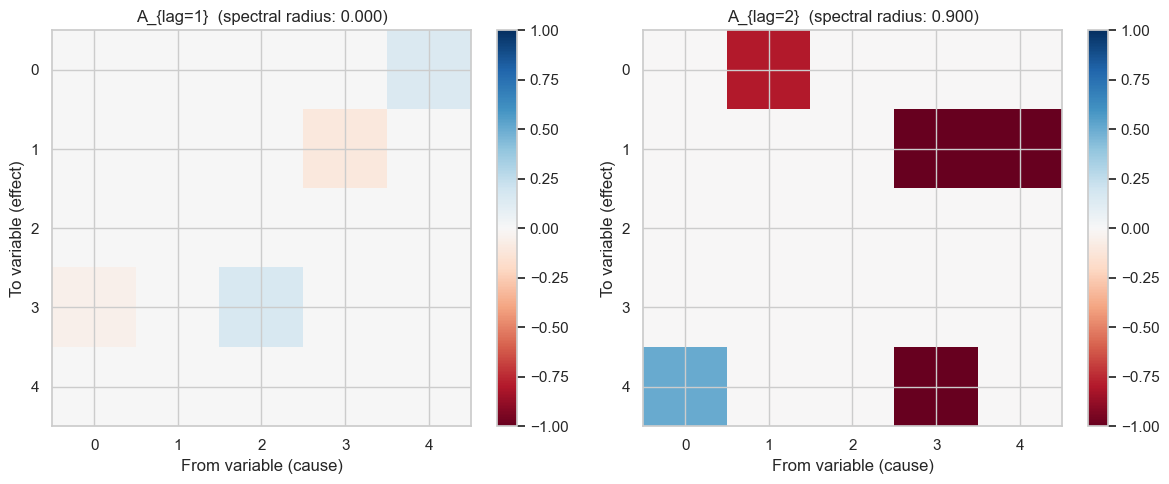

In [6]:
fig, axes = plt.subplots(1, LAG, figsize=(6 * LAG, 5))
if LAG == 1:
    axes = [axes]

for l, (A, ax) in enumerate(zip(generator.coef_matrices, axes)):
    im = ax.imshow(A, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    radius = np.max(np.abs(np.linalg.eigvals(A)))
    ax.set_title(f'A_{{lag={l+1}}}  (spectral radius: {radius:.3f})')
    ax.set_xlabel('From variable (cause)')
    ax.set_ylabel('To variable (effect)')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


## 4. Summary Statistics


In [7]:
import pandas as pd

rows = []
for v in range(N_VARS):
    rows.append({
        'Variable': f'V{v}',
        'Mean (class 0)': X[y == 0, :, v].mean(),
        'Std  (class 0)': X[y == 0, :, v].std(),
        'Mean (class 1)': X[y == 1, :, v].mean(),
        'Std  (class 1)': X[y == 1, :, v].std(),
    })

df = pd.DataFrame(rows).set_index('Variable')
df.round(4)


,Mean (class 0),Std (class 0),Mean (class 1),Std (class 1)
Variable,,,,
V0,-0.1368,0.4647,0.1257,0.4879
V1,0.1520,0.5599,-0.1375,0.5926
V2,-0.0016,0.0980,-0.0027,0.1015
V3,0.0099,0.1042,-0.0091,0.1046
V4,-0.0896,0.2896,0.0798,0.3062
